# Advance Bank Term Deposit

## Introduction
This notebook provides a detailed analysis of customer behavior and insights into factors influencing term deposit subscription.

## Load Dataset

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

# Set visualization style
sns.set(style="whitegrid")

# Load data
# The dataset appears to use standard comma separators
try:
    df = pd.read_csv('/content/data.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: 'data.csv' not found. Please ensure the dataset is in the directory.")

# Preview the data to verify columns
print(df.head())
print(df.info())

Dataset loaded successfully.
   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.con

## Customer Demographics Analysis

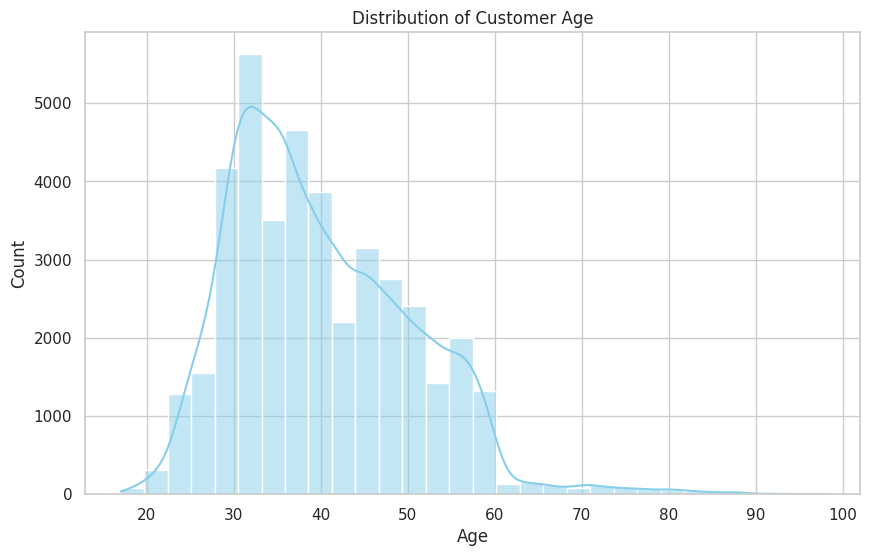

In [27]:
# Age distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

/tmp/ipython-input-1129131517.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='job', order=df['job'].value_counts().index, palette='viridis')


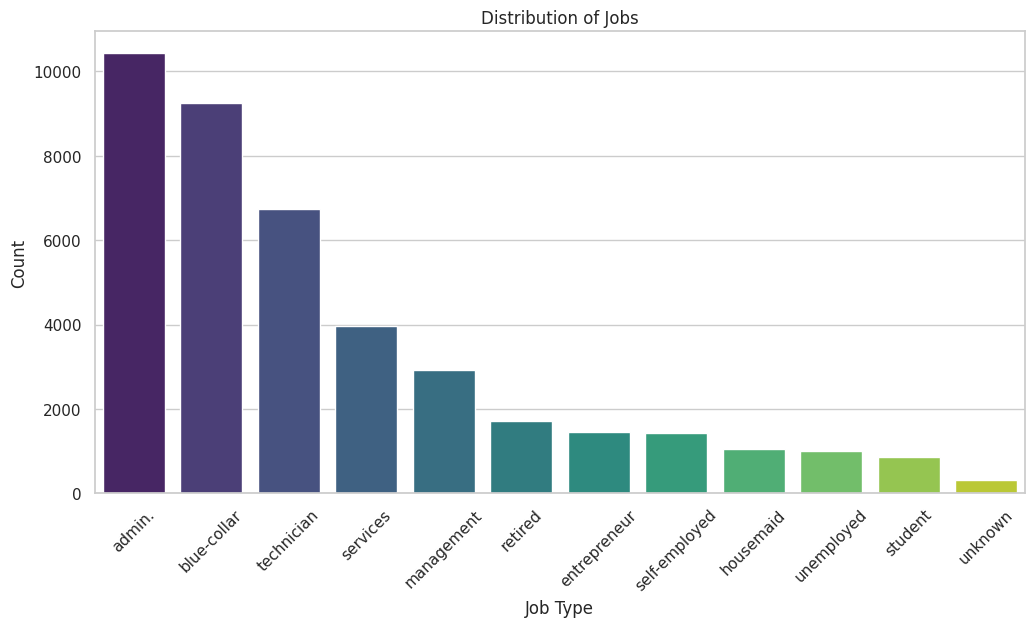

In [28]:
# Job distribution
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='job', order=df['job'].value_counts().index, palette='viridis')
plt.title('Distribution of Jobs')
plt.xticks(rotation=45)
plt.xlabel('Job Type')
plt.ylabel('Count')
plt.show()

## Balance & Deposit Trends

/tmp/ipython-input-1037887754.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='y', y='duration', palette='pastel')


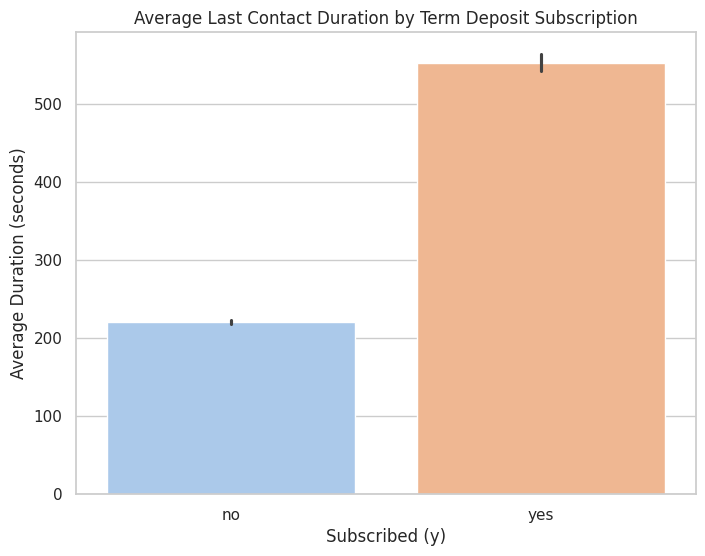

In [29]:
# Average duration by deposit subscription
plt.figure(figsize=(8, 6))
sns.barplot(data=df, x='y', y='duration', palette='pastel')
plt.title('Average Last Contact Duration by Term Deposit Subscription')
plt.xlabel('Subscribed (y)')
plt.ylabel('Average Duration (seconds)')
plt.show()

## Campaign Effectiveness

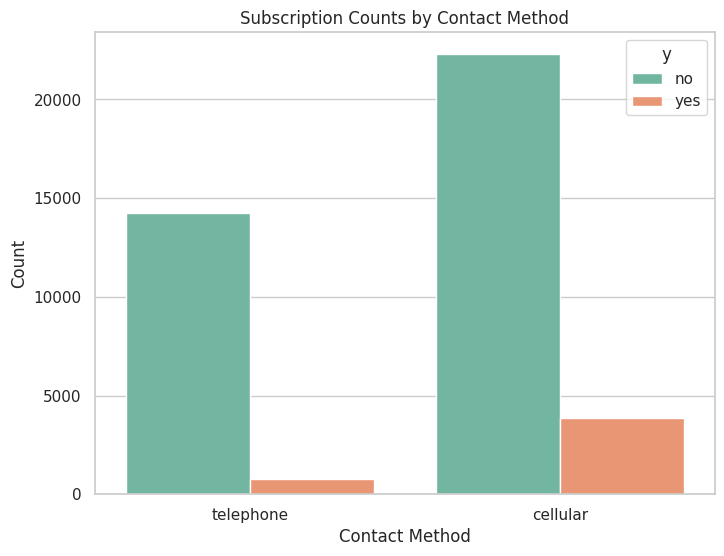

In [30]:
# Contact method analysis
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='contact', hue='y', palette='Set2')
plt.title('Subscription Counts by Contact Method')
plt.xlabel('Contact Method')
plt.ylabel('Count')
plt.show()

/tmp/ipython-input-1123195414.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='y', y='campaign', palette='coolwarm')


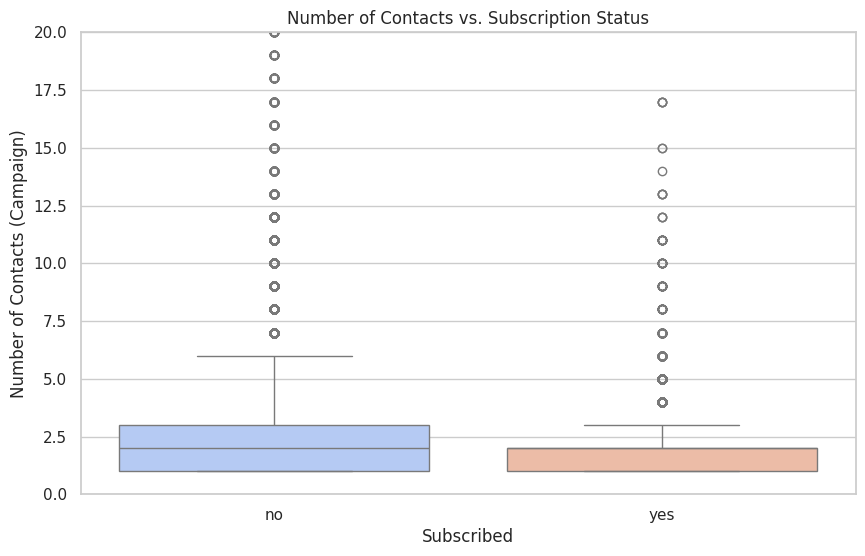

In [31]:
# Number of contacts (campaign) vs deposit subscription
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='y', y='campaign', palette='coolwarm')
plt.title('Number of Contacts vs. Subscription Status')
plt.xlabel('Subscribed')
plt.ylabel('Number of Contacts (Campaign)')
plt.ylim(0, 20)
plt.show()

## Correlation Heatmap

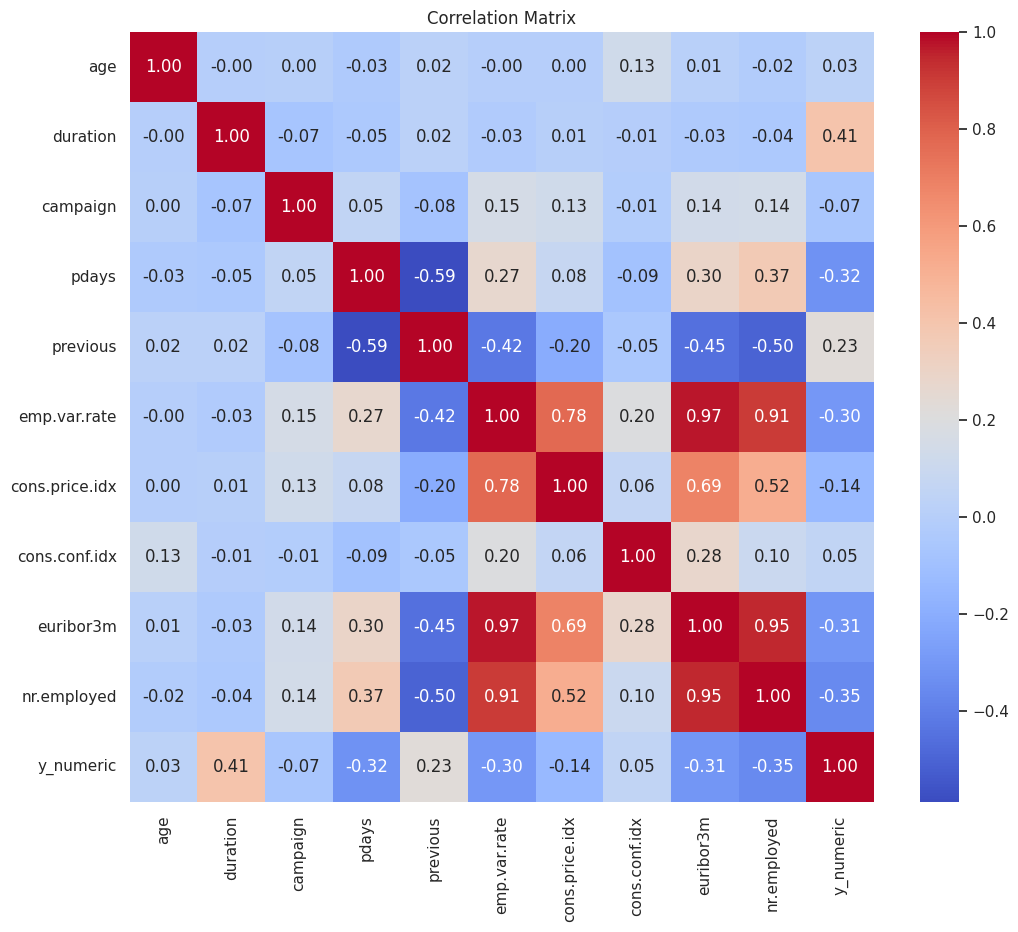

In [32]:
# Correlation of numerical variables
df['y_numeric'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)
numeric_df = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

## Predictive Modeling (Logistic Regression)

In [33]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
df_model = df.copy()
if df_model.isnull().values.any():
    print(f"Found {df_model.isnull().sum().sum()} missing values. Dropping affected rows...")
    df_model = df_model.dropna()
df_model['y_numeric'] = df_model['y'].apply(lambda x: 1 if x == 'yes' else 0)
X = df_model.drop(['y', 'y_numeric'], axis=1)
y = df_model['y_numeric']
X = pd.get_dummies(X, drop_first=True)
X = X.fillna(0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)

# Evaluation
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 0.9122764425022255

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95     10968
           1       0.68      0.42      0.52      1389

    accuracy                           0.91     12357
   macro avg       0.80      0.70      0.74     12357
weighted avg       0.90      0.91      0.90     12357



/tmp/ipython-input-899075843.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_features, x='Importance', y='Feature', palette='RdBu_r')


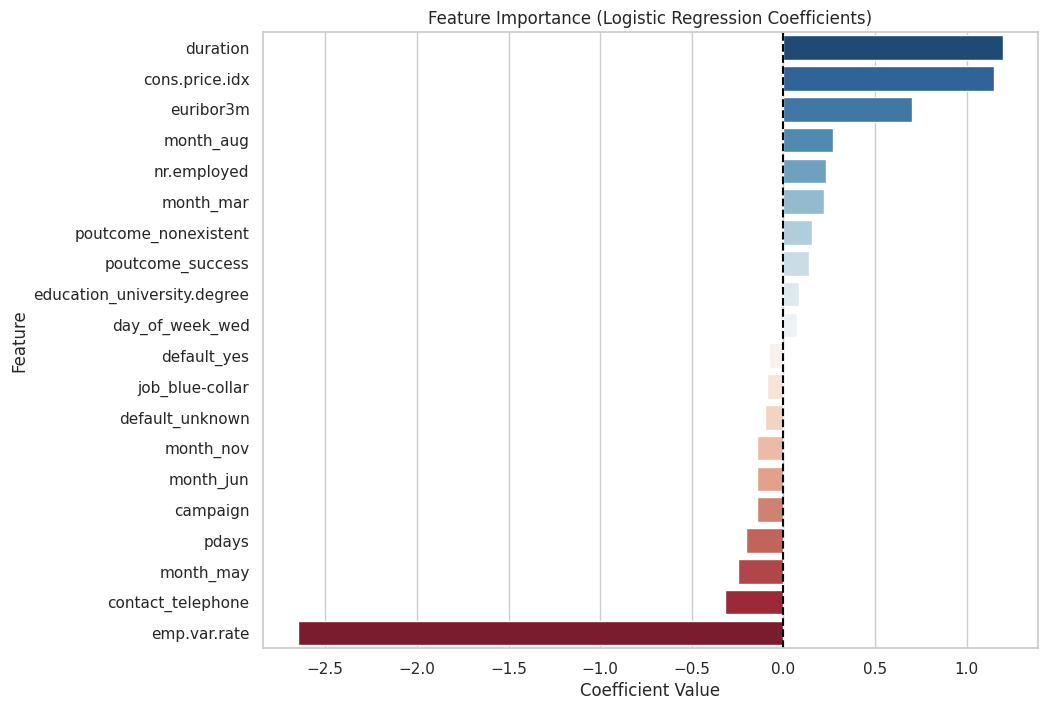

In [34]:
# Feature importance
import numpy as np

# Get coefficients and feature names
coefficients = model.coef_[0]
feature_names = X.columns

# Create a DataFrame for visualization
feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': coefficients})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# Plotting the top 10 positive and negative features
plt.figure(figsize=(10, 8))
# Combine top 10 positive and top 10 negative influences
top_features = pd.concat([feature_importance.head(10), feature_importance.tail(10)])

sns.barplot(data=top_features, x='Importance', y='Feature', palette='RdBu_r')
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.axvline(x=0, color='black', linestyle='--')
plt.show()

## Key Takeaways
- Certain age groups and job categories are more likely to subscribe.
- Higher balances correlate with higher subscription rates.
- Cellular contact is more effective than telephone.
- Campaign duration and number of contacts influence outcomes.
- Logistic regression shows which features are strongest predictors.